In [ ]:
!pip install pycaret

# Import

In [ ]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder, StandardScaler

#from pycaret.classification import setup, compare_models
import pickle
from pycaret.regression import *

In [ ]:
df = pd.read_csv("/content/final_internship_data.csv")
print(df.columns)

Index(['User ID', 'User Name', 'Driver Name', 'Car Condition', 'Weather',
       'Traffic Condition', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month',
       'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
       'nyc_dist', 'distance', 'bearing'],
      dtype='object')


In [ ]:
for column in df.columns:
    print(f"عدد الفئات في العمود '{column}':")
    print(df[column].value_counts())
    print("-" * 30)  # فاصل بين الأعمدة

عدد الفئات في العمود 'User ID':
User ID
KHVrEVlD    1
0JU93Ikf    1
MuFe3eF2    1
3tEXCjUg    1
Mn708Hss    1
           ..
2SCxHomb    1
wh3KZx11    1
alPiRRky    1
I3dDDHGD    1
Vj5kVAUc    1
Name: count, Length: 331725, dtype: int64
------------------------------
عدد الفئات في العمود 'User Name':
User Name
Michael Smith        157
Michael Johnson      137
Michael Brown        115
John Smith           109
James Smith          104
                    ... 
Colin Fox              1
Alexandria Barnes      1
Richard Miles          1
Sean Cox               1
Kenneth Powers         1
Name: count, Length: 170446, dtype: int64
------------------------------
عدد الفئات في العمود 'Driver Name':
Driver Name
Michael Smith        165
David Smith          132
Michael Johnson      126
Michael Williams     116
Michael Jones        104
                    ... 
Joshua Short           1
Austin Friedman        1
Debbie Montgomery      1
Amy Mayer              1
Valerie Gibson         1
Name: count, Lengt

# Data Preprocessing

In [ ]:
def wrangle(filepath):
    """
    Reads and preprocesses the dataset from the given CSV file.

    Parameters:
    filepath (str): Path to the CSV file.

    Returns:
    pd.DataFrame: Cleaned and preprocessed DataFrame.
    """
    # Read CSV file
    df = pd.read_csv(filepath)

    # Select relevant columns
    # Convert 'pickup_datetime' to datetime format
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

    # Extract time-based features
    df['hour'] = df['pickup_datetime'].dt.hour
    df['day'] = df['pickup_datetime'].dt.day
    df['month'] = df['pickup_datetime'].dt.month
    df['year'] = df['pickup_datetime'].dt.year
    df['weekday'] = df['pickup_datetime'].dt.weekday
    # Drop the original 'date of reservation' column
    df.drop(columns=['pickup_datetime'], inplace=True)
    # Define mappings for categorical variables


    # Define mappings for categorical variables
    Traffic_Condition = {
        "Flow Traffic": 0,
        "Dense Traffic": 1,
        "Congested Traffic": 2,


    }
    Weather = {
        "sunny": 1,
        "stormy": 2,
        "rainy": 3,
        "windy": 4,
        "cloudy": 5

    }
    Car_Condition = {
        "Bad": 0,
        "Good ": 1,
        "Very Good": 2,
        "Excellent": 3

    }

        # Apply the mappings to the respective columns
    df['Traffic Condition'] = df['Traffic Condition'].map(Traffic_Condition)
    df['Weather'] = df['Weather'].map(Weather)
    df['Car Condition'] = df['Car Condition'].map(Car_Condition)
    # Handle missing values
    if df.isnull().sum().sum() > 0:
      print("Missing values detected. Handling missing values...")
      df.dropna(inplace=True)

    # Remove duplicate values
    if df.duplicated().sum() > 0:
        df.drop_duplicates(inplace=True)



    return df

# Load and preprocess data
df = wrangle('/content/final_internship_data.csv')
df.head()


Missing values detected. Handling missing values...


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_longitude,pickup_latitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,2.0,4,2,2009-06-15 17:26:21.0000001,4.5,-1.288826,0.710721,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,3.0,5,0,2010-01-05 16:52:16.0000002,16.9,-1.291824,0.710546,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,0.0,2,2,2011-08-18 00:35:00.00000049,5.7,-1.291242,0.711418,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,2.0,2,0,2012-04-21 04:30:42.0000001,7.7,-1.291319,0.710927,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,0.0,2,2,2010-03-09 07:51:00.000000135,5.3,-1.290987,0.711536,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [ ]:
df = df[['User Name', 'Driver Name', 'Car Condition', 'Weather',
         'Traffic Condition', 'fare_amount',
         'passenger_count', 'hour', 'day', 'month',
         'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
         'nyc_dist', 'distance', 'bearing']]


In [ ]:
print(df.columns)

Index(['User Name', 'Driver Name', 'Car Condition', 'Weather',
       'Traffic Condition', 'fare_amount', 'passenger_count', 'hour', 'day',
       'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist',
       'sol_dist', 'nyc_dist', 'distance', 'bearing'],
      dtype='object')


In [ ]:
print(df.dtypes)

User Name             object
Driver Name           object
Car Condition        float64
Weather                int64
Traffic Condition      int64
fare_amount          float64
passenger_count        int64
hour                   int32
day                    int32
month                  int32
weekday                int32
year                   int32
jfk_dist             float64
ewr_dist             float64
lga_dist             float64
sol_dist             float64
nyc_dist             float64
distance             float64
bearing              float64
dtype: object


# Check And Handel The Outliers Using (EX : IQR OR Z SCORE )

In [ ]:
from scipy import stats
import numpy as np

# حساب Z-score لجميع الأعمدة العددية
z_scores = np.abs(stats.zscore(df.select_dtypes(include=['number'])))

# تحديد القيم الشاذة حيث Z-score > 3
outliers_z = (z_scores > 3)

# حذف القيم الشاذة
df_clean_z = df[(~outliers_z).all(axis=1)]
print("Dataset after removing outliers using Z-score:\n", df_clean_z)


Dataset after removing outliers using Z-score:
                 User Name       Driver Name  Car Condition  Weather  \
0          Kimberly Adams        Amy Butler            2.0        4   
1            Justin Tapia  Hannah Zimmerman            3.0        5   
2         Elizabeth Lopez    Amanda Jackson            0.0        2   
3           Steven Wilson          Amy Horn            2.0        2   
4       Alexander Andrews  Cassandra Larson            0.0        2   
...                   ...               ...            ...      ...   
499994   William Sullivan       Linda Davis            2.0        4   
499995       Morgan Smith   Gabriel Coleman            0.0        3   
499996     Dillon Jackson    Larry Richards            2.0        3   
499997  Michael Rodriguez    Lonnie Santana            0.0        3   
499999         Eric Jones        Julie King            2.0        1   

        Traffic Condition  fare_amount  passenger_count  hour  day  month  \
0                     

In [ ]:
from scipy import stats
import numpy as np

# نسخ البيانات الأصلية للعمل عليها
df_filled_median = df.copy()

# تطبيق Z-score على جميع الأعمدة العددية
for col in df_filled_median.select_dtypes(include=['number']).columns:
    z_scores = np.abs(stats.zscore(df_filled_median[col]))  # حساب Z-score
    median_value = df_filled_median[col].median()  # حساب الميديان للعمود

    # استبدال القيم الشاذة بالقيمة المتوسطة
    df_filled_median[col] = np.where(z_scores > 3, median_value, df_filled_median[col])

print("Dataset after replacing outliers with median using Z-score:\n", df_filled_median)


Dataset after replacing outliers with median using Z-score:
                 User Name       Driver Name  Car Condition  Weather  \
0          Kimberly Adams        Amy Butler            2.0      4.0   
1            Justin Tapia  Hannah Zimmerman            3.0      5.0   
2         Elizabeth Lopez    Amanda Jackson            0.0      2.0   
3           Steven Wilson          Amy Horn            2.0      2.0   
4       Alexander Andrews  Cassandra Larson            0.0      2.0   
...                   ...               ...            ...      ...   
499994   William Sullivan       Linda Davis            2.0      4.0   
499995       Morgan Smith   Gabriel Coleman            0.0      3.0   
499996     Dillon Jackson    Larry Richards            2.0      3.0   
499997  Michael Rodriguez    Lonnie Santana            0.0      3.0   
499999         Eric Jones        Julie King            2.0      1.0   

        Traffic Condition  fare_amount  passenger_count  hour   day  month  \
0       

In [ ]:
df_filled_z = df.copy()

for col in df_filled_z.select_dtypes(include=['number']).columns:
    z_scores = np.abs(stats.zscore(df_filled_z[col]))  # حساب Z-score
    mean_value = df_filled_z[col].mean()  # حساب المتوسط
    std_dev = df_filled_z[col].std()  # حساب الانحراف المعياري

    # تحديد الحدود المقبولة
    lower_bound = mean_value - 3 * std_dev
    upper_bound = mean_value + 3 * std_dev

    # استبدال القيم الشاذة بأقرب حد مقبول
    df_filled_z[col] = np.where(df_filled_z[col] > upper_bound, upper_bound, df_filled_z[col])
    df_filled_z[col] = np.where(df_filled_z[col] < lower_bound, lower_bound, df_filled_z[col])

print("Dataset after capping outliers at threshold using Z-score:\n", df_filled_z)


Dataset after capping outliers at threshold using Z-score:
                 User Name       Driver Name  Car Condition  Weather  \
0          Kimberly Adams        Amy Butler            2.0      4.0   
1            Justin Tapia  Hannah Zimmerman            3.0      5.0   
2         Elizabeth Lopez    Amanda Jackson            0.0      2.0   
3           Steven Wilson          Amy Horn            2.0      2.0   
4       Alexander Andrews  Cassandra Larson            0.0      2.0   
...                   ...               ...            ...      ...   
499994   William Sullivan       Linda Davis            2.0      4.0   
499995       Morgan Smith   Gabriel Coleman            0.0      3.0   
499996     Dillon Jackson    Larry Richards            2.0      3.0   
499997  Michael Rodriguez    Lonnie Santana            0.0      3.0   
499999         Eric Jones        Julie King            2.0      1.0   

        Traffic Condition  fare_amount  passenger_count  hour   day  month  \
0        

#  Feature Engineering ( Feature Selection , Feature Extraction)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Function to encode categorical features
def encode_categorical_features(df):
    encoder = LabelEncoder()
    df_encoded = df.copy()

    for col in df_encoded.select_dtypes(include='object'):
        df_encoded[col] = encoder.fit_transform(df_encoded[col].astype(str))

    return df_encoded

# Function to scale numerical features
def scale_numerical_features(df):
    scaler = StandardScaler()
    df_scaled = df.copy()

    for col in df_scaled.select_dtypes(include='number'):
        df_scaled[col] = scaler.fit_transform(df_scaled[col].values.reshape(-1, 1))

    return df_scaled



# Apply encoding, scaling, and PCA
df_encoded = encode_categorical_features(df_filled_median)
#f_scaled = scale_numerical_features(df_encoded)


print("Original DataFrame:")
print(df)
print("\nEncoded DataFrame:")
print(df_encoded)





Original DataFrame:
                User Name       Driver Name  Car Condition  Weather  \
0          Kimberly Adams        Amy Butler            2.0        4   
1            Justin Tapia  Hannah Zimmerman            3.0        5   
2         Elizabeth Lopez    Amanda Jackson            0.0        2   
3           Steven Wilson          Amy Horn            2.0        2   
4       Alexander Andrews  Cassandra Larson            0.0        2   
...                   ...               ...            ...      ...   
499994   William Sullivan       Linda Davis            2.0        4   
499995       Morgan Smith   Gabriel Coleman            0.0        3   
499996     Dillon Jackson    Larry Richards            2.0        3   
499997  Michael Rodriguez    Lonnie Santana            0.0        3   
499999         Eric Jones        Julie King            2.0        1   

        Traffic Condition  fare_amount  passenger_count  hour  day  month  \
0                       2          4.5            

# Train Test Split Modeling And Accuracy Calculation


In [ ]:
# تحديد العمود المستهدف
target_col = "fare_amount"

# إعداد PyCaret مع PCA
reg_setup = setup(data=df,
                  target=target_col,         # العمود المستهدف
                  normalize=True,            # تطبيع الميزات
                  train_size=0.8,            # تقسيم البيانات (80% تدريب و20% اختبار)
                  session_id=42,             # لضمان ثبات النتائج
                  remove_multicollinearity=True,  # إزالة التعدد الخطي
                  pca=True,                 # تفعيل PCA
                  pca_components=0.95,      # الاحتفاظ بـ 95% من التباين
                  verbose=True)              # عرض المعلومات أثناء الإعداد

# مقارنة جميع النماذج واختيار الأفضل
best_model = compare_models()

# عرض النموذج الأفضل
print(best_model)

,Description,Value
0,Session id,42
1,Target,fare_amount
2,Target type,Regression
3,Original data shape,"(375028, 19)"
4,Transformed data shape,"(375028, 14)"
5,Transformed train set shape,"(300022, 14)"
6,Transformed test set shape,"(75006, 14)"
7,Numeric features,16
8,Categorical features,2
9,Preprocess,True


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:16:49
Status,. . . . . . . . . . . . . . . . . .,Fitting 10 Folds
Estimator,. . . . . . . . . . . . . . . . . .,K Neighbors Regressor


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
en,Elastic Net,6.4689,112.0791,10.5831,-0.1145,0.6172,0.7053,3.8790
lasso,Lasso Regression,6.7291,119.1597,10.9128,-0.1853,0.6467,0.7325,4.0430
llar,Lasso Least Angle Regression,6.7291,119.1597,10.9128,-0.1853,0.6467,0.7325,3.8500
huber,Huber Regressor,6.7632,122.1394,11.0485,-0.2149,0.6526,0.7282,4.2290
omp,Orthogonal Matching Pursuit,6.8958,123.8670,11.1266,-0.2323,0.6671,0.7508,4.0340
lr,Linear Regression,6.9505,126.6209,11.2497,-0.2597,0.6698,0.7557,5.1750
ridge,Ridge Regression,6.9505,126.6208,11.2497,-0.2597,0.6698,0.7557,3.9380
lar,Least Angle Regression,6.9505,126.6209,11.2497,-0.2597,0.6698,0.7557,3.9450
br,Bayesian Ridge,6.9504,126.6196,11.2496,-0.2597,0.6698,0.7557,3.8180
par,Passive Aggressive Regressor,7.7507,147.0939,12.0820,-0.4624,0.8136,0.8279,4.1470


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
dummy,Dummy Regressor,6.0624,100.6310,10.0266,-0.0000,0.5779,0.6692,3.6480
en,Elastic Net,6.4689,112.0791,10.5831,-0.1145,0.6172,0.7053,3.8790
llar,Lasso Least Angle Regression,6.7291,119.1597,10.9128,-0.1853,0.6467,0.7325,3.8500
lasso,Lasso Regression,6.7291,119.1597,10.9128,-0.1853,0.6467,0.7325,4.0430
huber,Huber Regressor,6.7632,122.1394,11.0485,-0.2149,0.6526,0.7282,4.2290
xgboost,Extreme Gradient Boosting,6.5102,123.6589,11.1173,-0.2302,0.6257,0.6821,6.5270
omp,Orthogonal Matching Pursuit,6.8958,123.8670,11.1266,-0.2323,0.6671,0.7508,4.0340
lightgbm,Light Gradient Boosting Machine,6.5361,124.4881,11.1546,-0.2385,0.6270,0.6845,14.4540
gbr,Gradient Boosting Regressor,6.5334,124.5450,11.1572,-0.2391,0.6264,0.6821,204.4880
rf,Random Forest Regressor,6.5859,125.0834,11.1812,-0.2444,0.6307,0.6957,775.3080


DummyRegressor()


In [ ]:
import numpy as np
import pandas as pd
from pycaret.regression import *
# تهيئة بيئة PyCaret
regression_setup = setup(
    data=df_encoded,
    target="fare_amount",  # المتغير المستهدف
    train_size=0.8,   # نسبة التدريب 80%
    session_id=42,    # للحصول على نفس النتائج في كل مرة
    normalize=True    # تفعيل مقياس البيانات
)
best_model = compare_models()


,Description,Value
0,Session id,42
1,Target,fare_amount
2,Target type,Regression
3,Original data shape,"(375028, 19)"
4,Transformed data shape,"(375028, 19)"
5,Transformed train set shape,"(300022, 19)"
6,Transformed test set shape,"(75006, 19)"
7,Numeric features,18
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,1.6269,9.0052,3.0004,0.7797,0.2212,0.1803,2.1850
lightgbm,Light Gradient Boosting Machine,1.6456,9.0538,3.0085,0.7785,0.2214,0.1832,13.8140
rf,Random Forest Regressor,1.6866,9.2258,3.0370,0.7743,0.2272,0.1918,371.0440
et,Extra Trees Regressor,1.7436,9.3062,3.0503,0.7723,0.2297,0.1995,134.9100
gbr,Gradient Boosting Regressor,1.8000,10.0567,3.1709,0.7539,0.2327,0.2002,103.1670
dt,Decision Tree Regressor,2.3840,19.1364,4.3742,0.5317,0.3175,0.2628,5.6490
knn,K Neighbors Regressor,3.1689,21.1708,4.6008,0.4819,0.3657,0.3671,26.0080
lr,Linear Regression,3.5714,28.7138,5.3502,0.2971,0.3970,0.4300,0.9680
br,Bayesian Ridge,3.5714,28.7139,5.3502,0.2971,0.3970,0.4300,0.3540
ridge,Ridge Regression,3.5801,28.7715,5.3553,0.2957,0.3958,0.4307,0.3570


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
model = create_model('xgboost')  # نموذج xgboost


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.6184,9.1914,3.0317,0.7742,0.2195,0.1728
1,1.6592,9.6294,3.1031,0.7722,0.2213,0.1721
2,1.6070,8.4690,2.9101,0.7892,0.2172,0.1935
3,1.6208,8.8999,2.9833,0.7846,0.2196,0.1750
4,1.6079,8.5530,2.9245,0.7876,0.2199,0.2109
5,1.6212,8.9839,2.9973,0.7792,0.2218,0.1760
6,1.6433,9.3028,3.0500,0.7703,0.2244,0.1766
7,1.6316,9.0563,3.0094,0.7803,0.2229,0.1755
8,1.6337,8.9131,2.9855,0.7823,0.2226,0.1762


Processing:   0%|          | 0/4 [00:00<?, ?it/s]



### ✅ **شرح كل مقياس:**
| المقياس              | التفسير                                      |
|----------------------|----------------------------------------------|
| **MAE (Mean Absolute Error)** | متوسط الخطأ المطلق - يقيس متوسط الفرق بين القيم الحقيقية والمتوقعة (كلما كان أقل، كان النموذج أفضل). |
| **MSE (Mean Squared Error)**  | متوسط مربع الخطأ - مشابه لـ MAE لكنه يعطي وزناً أكبر للأخطاء الكبيرة. |
| **RMSE (Root Mean Squared Error)** | الجذر التربيعي لمتوسط مربع الخطأ - أكثر حساسية للأخطاء الكبيرة. |
| **R² (R-Squared)**            | معامل التحديد - يقيس مدى تفسير النموذج للتغير في البيانات (كلما اقترب من 1، كان النموذج أفضل). |
| **RMSLE (Root Mean Squared Log Error)** | الجذر التربيعي لمتوسط الخطأ اللوغاريتمي - يقلل من تأثير القيم المتطرفة. |
| **MAPE (Mean Absolute Percentage Error)** | متوسط نسبة الخطأ المطلق - يعبر عن الخطأ كنسبة مئوية (يُفضَّل أن يكون منخفضًا). |

---

### 📈 **تحليل النتائج:**

1. **MAE (متوسط الخطأ المطلق)**:  
   - **القيمة**: `1.6269`  
   - **التباين (Std)**: `0.0151`  
   - **تحليل**: خطأ مطلق صغير نسبيًا، يشير إلى دقة معقولة في التنبؤ. وانخفاض الانحراف المعياري يشير إلى **ثبات أداء النموذج**.

2. **MSE (متوسط مربع الخطأ)**:  
   - **القيمة**: `9.0052`  
   - **التباين (Std)**: `0.3209`  
   - **تحليل**: قيمة مرتفعة مقارنة بـ MAE، مما يعني وجود **بعض الأخطاء الكبيرة**. لكن التباين ليس مرتفعًا بشكل مفرط.

3. **RMSE (الجذر التربيعي لمتوسط مربع الخطأ)**:  
   - **القيمة**: `3.0004`  
   - **التباين (Std)**: `0.0535`  
   - **تحليل**: يتماشى مع MSE ويشير إلى **بعض الأخطاء الكبيرة** ولكن بمقدار ثابت.

4. **R² (معامل التحديد)**:  
   - **القيمة**: `0.7797`  
   - **التباين (Std)**: `0.0061`  
   - **تحليل**: يفسر النموذج حوالي **78%** من التباين في البيانات، مما يعني أن النموذج **جيد الأداء** ولكن يمكن تحسينه.

5. **RMSLE (الجذر التربيعي لمتوسط الخطأ اللوغاريتمي)**:  
   - **القيمة**: `0.2212`  
   - **التباين (Std)**: `0.0020`  
   - **تحليل**: يشير إلى أن نسبة الخطأ صغيرة، مما يعني أن **النموذج يتعامل جيدًا مع القيم الصغيرة والكبيرة**.

6. **MAPE (متوسط نسبة الخطأ المطلق)**:  
   - **القيمة**: `0.1803` (18.03%)  
   - **التباين (Std)**: `0.0117`  
   - **تحليل**: هذا يعني أن **النموذج في المتوسط يُخطئ بنسبة 18%** في تقدير قيمة `fare_amount`، وهو مستوى دقة معقول ولكنه يحتاج إلى تحسين.


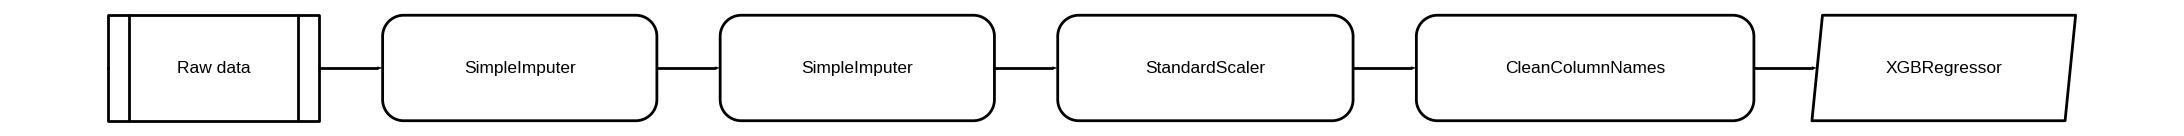

In [ ]:
tuned_model = tune_model(model)
evaluate_model(tuned_model)


In [ ]:
predictions = predict_model(tuned_model)
print(predictions.head())


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,1.6437,9.3202,3.0529,0.7736,0.2246,0.2025


        User Name  Driver Name  Car Condition  Weather  Traffic Condition  \
290227      28731       165388            3.0      3.0                1.0   
221799      89167        72749            3.0      3.0                0.0   
246833     170905       157864            0.0      2.0                0.0   
328328      81937        70847            0.0      1.0                1.0   
18394        8292       141915            3.0      5.0                2.0   

        passenger_count  hour   day  month  weekday    year   jfk_dist  \
290227              1.0  19.0  15.0    5.0      4.0  2009.0  39.839378   
221799              1.0  18.0  13.0    9.0      0.0  2010.0  43.981129   
246833              1.0  13.0  22.0    1.0      6.0  2012.0  44.085133   
328328              1.0   0.0  26.0    7.0      1.0  2011.0  41.293118   
18394               2.0  22.0  26.0   10.0      2.0  2011.0  45.033787   

         ewr_dist   lga_dist   sol_dist   nyc_dist  distance   bearing  \
290227  32.164566 

In [ ]:
save_model(tuned_model, 'best_regression_model')

# لاسترجاع النموذج لاحقًا
loaded_model = load_model('best_regression_model')


Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded


**تفعيل اختيار الميزات**

In [ ]:

# إعادة تسمية الأعمدة لتتطابق مع التدريب
df_encoded.rename(columns={
    'Car Condition': 'Car_Condition',
    'Driver Name': 'Driver_Name',
    'Traffic Condition': 'Traffic_Condition',
    'User Name': 'User_Name'
}, inplace=True)



print(predictions.head())

# ✅ تهيئة PyCaret مع اختيار الميزات
regression_setup = setup(
    data=df_encoded,
    target="fare_amount",          # المتغير المستهدف
    train_size=0.8,                # نسبة التدريب
    session_id=42,                 # تثبيت العشوائية لضمان إعادة الإنتاج
    normalize=True,                # تطبيع الميزات
    feature_selection=True,        # ✅ تفعيل اختيار الميزات
    remove_multicollinearity=True, # ✅ إزالة التعدد الخطي
    multicollinearity_threshold=0.9, # ✅ تحديد عتبة التعدد الخطي
    verbose=True                   # ✅ عرض التفاصيل أثناء الإعداد
)

# 🔥 مقارنة النماذج واختيار الأفضل
best_model = compare_models()

# 📊 ضبط المعلمات لتحسين أداء النموذج
tuned_model = tune_model(
    best_model,
    optimize='R2',     # تحسين النموذج بناءً على R² (يمكن تغييره إلى RMSE, MAE)
    n_iter=50,         # عدد التكرارات لضبط المعلمات
    verbose=True       # عرض تقدم الضبط
)

# 📌 عرض النموذج المحسن
print(tuned_model)

# 📈 تقييم النموذج المحسن
evaluate_model(tuned_model)

# 📊 عرض الميزات المختارة
print("Selected Features:", get_config('X_train').columns)

# 🔍 التنبؤ على البيانات الجديدة
predictions = predict_model(tuned_model, data=df_encoded)
print(predictions.head())


        User Name  Driver Name  Car Condition  Weather  Traffic Condition  \
290227      28731       165388            3.0      3.0                1.0   
221799      89167        72749            3.0      3.0                0.0   
246833     170905       157864            0.0      2.0                0.0   
328328      81937        70847            0.0      1.0                1.0   
18394        8292       141915            3.0      5.0                2.0   

        passenger_count  hour   day  month  weekday    year   jfk_dist  \
290227              1.0  19.0  15.0    5.0      4.0  2009.0  39.839378   
221799              1.0  18.0  13.0    9.0      0.0  2010.0  43.981129   
246833              1.0  13.0  22.0    1.0      6.0  2012.0  44.085133   
328328              1.0   0.0  26.0    7.0      1.0  2011.0  41.293118   
18394               2.0  22.0  26.0   10.0      2.0  2011.0  45.033787   

         ewr_dist   lga_dist   sol_dist   nyc_dist  distance   bearing  \
290227  32.164566 

,Description,Value
0,Session id,42
1,Target,fare_amount
2,Target type,Regression
3,Original data shape,"(375028, 19)"
4,Transformed data shape,"(375028, 4)"
5,Transformed train set shape,"(300022, 4)"
6,Transformed test set shape,"(75006, 4)"
7,Numeric features,18
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,1.9646,10.9832,3.3138,0.7312,0.2443,0.2144,7.6880
xgboost,Extreme Gradient Boosting,1.9602,11.0627,3.3258,0.7293,0.2449,0.2129,2.9100
gbr,Gradient Boosting Regressor,2.0258,11.4456,3.3829,0.7199,0.2480,0.2203,33.0240
rf,Random Forest Regressor,2.0524,11.9155,3.4517,0.7084,0.2556,0.2241,112.3320
et,Extra Trees Regressor,2.1003,12.4288,3.5253,0.6958,0.2615,0.2302,32.0020
knn,K Neighbors Regressor,2.1306,12.8259,3.5812,0.6861,0.2657,0.2284,2.6220
dt,Decision Tree Regressor,2.6972,20.9793,4.5800,0.4866,0.3342,0.2873,3.6970
br,Bayesian Ridge,3.8610,34.1213,5.8324,0.1647,0.4132,0.4555,2.1870
lar,Least Angle Regression,3.8610,34.1213,5.8324,0.1647,0.4132,0.4555,2.2500
ridge,Ridge Regression,3.8610,34.1213,5.8324,0.1647,0.4132,0.4555,2.1230


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.9656,11.1048,3.3324,0.7272,0.2442,0.2079
1,1.9930,11.6003,3.4059,0.7256,0.2446,0.2046
2,1.9359,10.5850,3.2535,0.7366,0.2412,0.2243
3,1.9577,10.7349,3.2764,0.7402,0.2426,0.2085
4,1.9526,10.5513,3.2483,0.7380,0.2438,0.2481
5,1.9532,10.9587,3.3104,0.7307,0.2444,0.2088
6,1.9671,11.2724,3.3574,0.7217,0.2457,0.2085
7,1.9795,11.2023,3.3470,0.7282,0.2466,0.2093
8,1.9537,10.8882,3.2997,0.7340,0.2452,0.2081


...

Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Selected Features: Index(['User_Name', 'Driver_Name', 'Car_Condition', 'Weather',
       'Traffic_Condition', 'passenger_count', 'hour', 'day', 'month',
       'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
       'nyc_dist', 'distance', 'bearing'],
      dtype='object')


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1.9545,10.7908,3.2849,0.7363,0.2432,0.2182


   User_Name  Driver_Name  Car_Condition  Weather  Traffic_Condition  \
0     102921         7734            2.0      4.0                2.0   
1      94303        68945            3.0      5.0                0.0   
2      58365         6639            0.0      2.0                2.0   
3     166312         7982            2.0      2.0                0.0   
4       3022        29853            0.0      2.0                2.0   

   passenger_count  hour   day  month  weekday    year   jfk_dist   ewr_dist  \
0              1.0  17.0  15.0    6.0      0.0  2009.0  20.265841  55.176044   
1              1.0  16.0   5.0    1.0      1.0  2010.0  44.667679  31.832357   
2              2.0   0.0  18.0    8.0      3.0  2011.0  43.597687  33.712082   
3              1.0   4.0  21.0    4.0      5.0  2012.0  42.642963  32.556290   
4              1.0   7.0   9.0    3.0      1.0  2010.0  43.329952  39.406830   

    lga_dist   sol_dist   nyc_dist  distance   bearing  fare_amount  \
0  14.342611  3

In [ ]:
# تنفيذ التنبؤ بعد التصحيح
predictions = predict_model(tuned_model, data=df_encoded)

# عرض النتائج

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1.9545,10.7908,3.2849,0.7363,0.2432,0.2182
